# 01 — Data Collection
## The 15-Minute Shanghai Project · Track C: Affordability

---

## Literature Review

**The 15-minute city.** Moreno et al. (2021) framed the 15-minute city (15MC): every resident should
be able to reach the essential functions of daily life within a 15-minute walk or cycle. The idea
reorganises the city around *proximity* rather than mobility and gained policy traction after COVID-19.
Turning the slogan into a reproducible metric requires two decisions — *how* accessibility is measured,
and *whose* access is counted.

**Measuring accessibility.** We follow the GIS methodology of **Mouratidis (2026)**, the most recent
comprehensive treatment, on three points. First, accessibility is computed as **cumulative
opportunities** — the number of destinations of each function reachable within the 15-minute catchment
— which Mouratidis argues is more intuitive than distance-decay measures and, unlike time-to-nearest,
*"allows the assessment of different levels of accessibility … across different areas"*. Second, travel
times are computed on the street **network**, not straight-line buffers: Zhang et al. (2022) show
buffers overestimate reachable area by 20–40% in dense Chinese cities where rivers, elevated roads and
gated compounds form hard barriers, so we route on an OpenStreetMap graph (Notebook 02). Third, the
catchment uses an **inclusive walking speed of 3.39 km/h** (850 m in 15 minutes; Bohannon & Williams
Andrews, 2011, adopted by Mouratidis), so the measure reflects access for slower and older pedestrians
rather than a fit median adult.

**The amenity basket.** We score six essential "lower-order" daily functions — food, healthcare,
education, recreation/green space, public-transport stops, and daily services — the common core of the
15MC literature (Bruno et al., 2024; Mouratidis, 2026). Following Mouratidis's caution against
aggregating dissimilar facilities, the education function uses a dedicated 2026 AMap census of kindergartens and K-12 schools (EDU 2026), not private tutoring
(培训机构) or the broad SHP school/culture category, both excluded from the baseline. POIs come from AMap (高德) rather than OpenStreetMap, which
substantially under-represents commercial and service POIs in Chinese cities — a limitation Bruno et al.
(2024) acknowledge in their global ~10,000-city analysis, where Shanghai reaches only ~30% full-basket
walking access (≈55% by bike); these figures benchmark our results. The baseline uses walking and
cycling only, the non-car modes definitional to the 15MC (Moreno et al., 2021); transit and car are
computed for comparison, echoing Mouratidis's call to assess public-transport supply alongside
proximity. Because firm-size heterogeneity imposes a structural lower bound on commuting distance that
local planning cannot remove (Barthelemy, 2026), we read transit accessibility as a proxy for reaching
distributed daily services, not for commuting feasibility.

**Equity and affordability (Track C).** Vale & Lopes (2023) shift the question from *whether* a city is
15-minute to *for whom*: a strong city-average can hide steep within-city inequality (high pseudo-Gini),
and walkable, well-served neighbourhoods tend to command price premiums — potentially making the 15MC
self-defeating for lower-income residents. Track C operationalises this critique for Shanghai. We
regress Anjuke listing prices per m² on the H3-level accessibility score to test the premium, and flag
"sweet-spot" hexes — high accessibility with below-predicted rent — as the web app's recommender
targets. We widen affordability beyond price with district income-to-rent ratios, proximity to
social/affordable housing, free public amenities, a community-vs-hospital healthcare mix, and a
public-vs-private school mix, so the map distinguishes neighbourhoods that are accessible *and*
attainable.

#### Methodological choices

| Choice | Justification | Source |
|--------|--------------|--------|
| Cumulative-opportunities measure | Intuitive; shows levels of access; avoids the near-threshold zero of time-decay | Mouratidis (2026) |
| Network routing over buffers | Buffers overestimate reach by 20–40% in dense China | Zhang et al. (2022) |
| Inclusive 3.39 km/h walk speed | 15MC must be walkable by everyone, incl. older adults | Mouratidis (2026); Bohannon & Williams Andrews (2011) |
| Disaggregated facilities (schools ≠ tutoring) | Dissimilar destinations do not substitute for each other | Mouratidis (2026) |
| AMap over OSM for POIs | OSM under-represents POIs in Chinese cities | Bruno et al. (2024) |
| Walk + bike for baseline | 15MC is fundamentally non-car | Moreno et al. (2021) |
| Rent regression + Gini lens | Tests the accessibility–affordability trade-off | Vale & Lopes (2023) |
| Transit = service proxy, not commute | Commuting structurally constrained by firm sizes | Barthelemy (2026) |

#### References

- Barthelemy, M. (2026). Why urban heterogeneity limits the 15-minute city. *arXiv preprint arXiv:2603.12122.*
- Bohannon, R. W., & Williams Andrews, A. (2011). Normal walking speed: a descriptive meta-analysis. *Physiotherapy, 97*(3), 182–189.
- Bruno, M., Melo, H. P. M., Campanelli, B., & Loreto, V. (2024). A universal framework for inclusive 15-minute cities. *Nature Cities, 1*, 633–641.
- Moreno, C., Allam, Z., Chabaud, D., Gall, C., & Pratlong, F. (2021). Introducing the '15-minute city': Sustainability, resilience and place identity in future post-pandemic cities. *Smart Cities, 4*, 93–111.
- Mouratidis, K. (2026). The 15-minute city revisited: A GIS approach to measuring, visualizing, and analyzing accessibility by proximity and by public transport supply. *Travel Behaviour and Society, 42*, 101151.
- Vale, D., & Lopes, A. (2023). Accessibility inequality across Europe: A comparison of 15-minute pedestrian accessibility in cities with 100,000 or more inhabitants. *npj Urban Sustainability, 3*, 55.
- Zhang, S., Zhen, F., Kong, Y., Lobsang, T., & Zou, S. (2022). Towards a 15-minute city: A network-based evaluation framework. *Environment and Planning B: Urban Analytics and City Science, 50*, 500–514.

---

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_DIR   = Path('.')
POI_DIR    = DATA_DIR / 'POI 2024/csv格式/已分类'
URBAN_DIR  = DATA_DIR / 'urban data'
CACHE_DIR  = DATA_DIR / 'cache'
CACHE_DIR.mkdir(exist_ok=True)

print('Paths OK:', all(p.exists() for p in [DATA_DIR, POI_DIR, URBAN_DIR]))

Paths OK: True


## 1. POI Category Mapping

Following Bruno et al. (2024), we map AMap's 21 category files to a 9-category basket,
then collapse to 6 baseline indicators. Track C uses 3 additional splits within existing categories.

In [2]:
# AMap filename suffix → (baseline_indicator, track_c_sub_indicator)
CATEGORY_MAP = {
    '餐饮服务':     ('food_supplies',   None),
    '购物服务':     ('food_supplies',   None),
    '医疗保健服务': ('healthcare',      'healthcare_public_ratio'),
    '科教文化服务': ('education',       'education_public_ratio'),
    '体育休闲服务': ('recreation',      None),
    '风景名胜':     ('recreation',      None),
    '交通设施服务': ('transit',         None),
    '生活服务':     ('daily_services',  None),
    '公共设施':     ('daily_services',  'free_public_amenities'),
    '政府机构及社会团体': ('daily_services', None),
    '公司企业':     (None,             'employment'),
    # unused
    '住宿服务': (None, None), '金融保险服务': (None, None),
    '商务住宅': (None, None), '汽车服务': (None, None),
    '道路附属设施': (None, None), '地名地址信息': (None, None),
}

# Refined midType whitelist — only daily-use POI types per category
# Rationale: Bruno et al. (2024) note that amenities should be of "daily or frequent use";
# we exclude destination-only facilities (stadiums, resorts, parking, tourist sites, etc.)
MIDTYPE_WHITELIST = {
    '交通设施服务': [
        '公交车站',      # bus stops — core daily transit
        '地铁站',        # metro stations
        '轮渡站',        # ferry stops (relevant in Shanghai with many rivers)
    ],
    '体育休闲服务': [
        '运动场馆',          # sports courts and community gyms
        '体育休闲服务场所',   # general sport/leisure facilities
        '休闲场所',          # leisure spaces (community level)
        # excluded: 娱乐场所 (entertainment/nightlife → Track B),
        #           影剧院 (cinemas → Track B), 度假疗养场所 (resorts), 高尔夫相关
    ],
    '风景名胜': [
        '公园广场',      # parks and plazas — genuine green space daily access
        # excluded: 风景名胜相关 / 风景名胜 (tourist destinations, not local daily need)
    ],
    '医疗保健服务': [
        '诊所',              # GPs / clinics — most important for daily healthcare
        '医药保健销售店',     # pharmacies — daily need
        '医疗保健服务场所',   # community health centres
        '综合医院',          # general hospitals (kept for Track C public/private ratio)
        '急救中心',          # emergency centres
        # excluded: 动物医疗场所 (veterinary), 疾病预防机构, 专科医院 (specialist → not daily)
    ],
    '科教文化服务': [
        '学校',          # K12 schools — INCLUDED: 2023 SHP school records are correct
                         # (2024 AMap CSV school records were wrong/incomplete per professor)
        '图书馆',        # libraries
        '文化宫',        # community cultural centres (grassroots civic facilities)
        '培训机构',      # tutoring/training — very common daily-use in Chinese cities
        # excluded: 科研机构, 驾校, 传媒机构, 博物馆, 展览馆, 会展中心, 美术馆, 科技馆
    ],
    '购物服务': [
        '便民商店/便利店',  # convenience stores — highest daily relevance
        '超级市场',         # supermarkets
        '综合市场',         # fresh produce / general markets
        # excluded: 家居建材市场 (41k! home furnishing), 专卖店, 服装鞋帽皮具店,
        #           家电电子卖场, 花鸟鱼虫市场, 体育用品店, 商场 (malls — destination)
    ],
    '餐饮服务': None,  # keep all dining types — food access is universally valid
    '生活服务': [
        '生活服务场所',  # general daily services
        '美容美发店',    # hair salons — genuine daily service in Chinese cities
        '维修站点',      # repair shops
        '洗衣店',        # laundry
        '邮局',          # post offices
        # excluded: 共享设备 (25k shared e-bikes etc.), 物流速递, 中介机构,
        #           摄影冲印店, 彩票, 事务所, 人才市场, 旅行社
    ],
    '公共设施': [
        '公共设施',      # community public facilities
        # excluded: 公共厕所 (14k public toilets), 紧急避难场所, 公用电话
    ],
    '政府机构及社会团体': [
        '政府机关',      # government offices (admin services)
        '社会团体',      # community organisations
        # excluded: 公检法机构, 工商税务, 外国机构, 民主党派
    ],
    '公司企业': None,  # keep all — used for Track C employment access only
}

BASELINE_INDICATORS = ['food_supplies', 'healthcare', 'education',
                        'recreation', 'transit', 'daily_services']

print(f'{len(BASELINE_INDICATORS)} baseline indicators defined')
print('Whitelist defined for', len([k for k,v in MIDTYPE_WHITELIST.items() if v is not None]),
      'categories (None = keep all)')

6 baseline indicators defined
Whitelist defined for 9 categories (None = keep all)


## 2. Load & Validate POI Data (2023 SHP)

Following the professor's recommendation, we use the **2023 AMap SHP dataset** as the primary POI
source for all categories. It is more complete than the 2024 CSV export (~1.49M records total vs
~511k after whitelist filtering from the 2024 CSV) and, critically, its school records are correct.

The 17 SHP files are read **directly from the zip archive** via GDAL's `/vsizip/` virtual filesystem
— no disk extraction required. Each file is already in **WGS-84** (EPSG:4326); coordinates are
extracted directly from the `geometry` column.

In [3]:
import os, zipfile, pathlib
from collections import defaultdict
import geopandas as gpd
import pandas as pd

SHP_ZIP = os.path.abspath('2023_Shp.zip')

# Group zip entries by stem so we can write all companion files together
# (.shp, .dbf, .shx, .prj, .cpg are all required to open a shapefile)
TMPDIR = pathlib.Path('/tmp/shp_work')
TMPDIR.mkdir(exist_ok=True)

with zipfile.ZipFile(SHP_ZIP) as _zf:
    _entries = [e for e in _zf.infolist() if not e.filename.startswith('__MACOSX')]

stems = defaultdict(list)
for e in _entries:
    if '.' in e.filename:
        stem = e.filename.rsplit('.', 1)[0]
        stems[stem].append(e)

shp_stems = sorted(s for s, es in stems.items() if any(e.filename.endswith('.shp') for e in es))
print(f'2023 SHP archive: {len(shp_stems)} categories\n')

poi_frames = {}
with zipfile.ZipFile(SHP_ZIP) as zf:
    for i, stem in enumerate(shp_stems):
        safe = str(TMPDIR / f'shp_{i:02d}')

        # Extract all companion files to /tmp with a safe ASCII name
        for e in stems[stem]:
            ext = e.filename.rsplit('.', 1)[1].lower()
            with zf.open(e) as fin, open(f'{safe}.{ext}', 'wb') as fout:
                fout.write(fin.read())

        gdf = gpd.read_file(f'{safe}.shp')

        # Clean up temp files immediately to conserve /tmp space
        for p in TMPDIR.glob(f'shp_{i:02d}.*'):
            p.unlink()

        if '行业大' not in gdf.columns or len(gdf) == 0:
            continue
        category = gdf['行业大'].iloc[0]

        if category not in CATEGORY_MAP:
            print(f'  SKIP (unmapped): {category}')
            continue
        baseline_ind, track_c_ind = CATEGORY_MAP[category]
        if baseline_ind is None and track_c_ind is None:
            continue

        before = len(gdf)

        # Spatial bounds filter (geometry already WGS-84)
        gdf = gdf[gdf.geometry.notna()]
        gdf = gdf[
            gdf.geometry.x.between(120.8, 122.2) &
            gdf.geometry.y.between(30.6, 31.9)
        ]
        after_bounds = len(gdf)

        # Apply midType whitelist using 行业中 (equivalent to midType in 2024 CSV)
        allowed = MIDTYPE_WHITELIST.get(category)
        if allowed is not None:
            gdf = gdf[gdf['行业中'].isin(allowed)]

        # Normalise to standard schema
        gdf = gdf.copy()
        gdf['wgs84Lng']            = gdf.geometry.x
        gdf['wgs84Lat']            = gdf.geometry.y
        gdf['category']            = category
        gdf['baseline_indicator']  = baseline_ind
        gdf['track_c_indicator']   = track_c_ind
        gdf = gdf.rename(columns={'行业大': 'bigType', '行业中': 'midType'})

        poi_frames[category] = gdf[['name', 'bigType', 'midType', 'wgs84Lng', 'wgs84Lat',
                                      'category', 'baseline_indicator', 'track_c_indicator']]

        dropped_b = before - after_bounds
        dropped_m = after_bounds - len(poi_frames[category])
        print(f'  {category:22s}: {len(poi_frames[category]):>7,} POIs  '
              f'(bounds −{dropped_b:,}  midType −{dropped_m:,})')

poi_all = pd.concat(poi_frames.values(), ignore_index=True)

# Mouratidis (2026): the education function means schools (kindergarten/primary/secondary),
# NOT private tutoring; and dissimilar facilities should not be aggregated into one category.
# We therefore EXCLUDE 培训机构 (private tutoring/cram schools) from the 'education' baseline
# indicator. The rows are KEPT in the dataset (for the Track C public-vs-private school ratio
# in NB03) but their baseline_indicator is cleared so they do not inflate education access.
n_tutoring = int((poi_all['midType'] == '培训机构').sum())
poi_all.loc[poi_all['midType'] == '培训机构', 'baseline_indicator'] = None

print(f'\nTotal POIs loaded: {len(poi_all):,}')
print(f'(培训机构 retained in data but excluded from education baseline: {n_tutoring:,} POIs)')
print(poi_all.groupby('baseline_indicator').size().rename('count').to_frame().to_string())

2023 SHP archive: 17 categories



  政府机构及社会团体             :  42,318 POIs  (bounds −0  midType −9,906)


  餐饮服务                  : 142,087 POIs  (bounds −0  midType −0)


  风景名胜                  :   1,799 POIs  (bounds −0  midType −4,904)


  交通设施服务                :  19,537 POIs  (bounds −0  midType −66,528)


...

  公司企业                  : 142,224 POIs  (bounds −0  midType −0)


  公共设施                  :     203 POIs  (bounds −0  midType −17,802)


  医疗保健服务                :  19,131 POIs  (bounds −0  midType −4,004)


  科教文化服务                :  26,210 POIs  (bounds −0  midType −13,666)


  生活服务                  :  75,306 POIs  (bounds −0  midType −72,039)

Total POIs loaded: 536,267
(培训机构 retained in data but excluded from education baseline: 16,390 POIs)
                     count
baseline_indicator        
daily_services      117827
education             9820
food_supplies       191018
healthcare           19131
recreation           20320
transit              19537


### 2b. EDU 2026 Schools — Education Baseline Source

A dedicated **2026 Gaode/AMap API dataset** (~4,143 records: kindergartens, primary, middle and high schools; typecodes 141204/141203/141202) is used as the **baseline education indicator**. It is preferred over the 2023 SHP `科教文化服务` category because that set conflates *all* school types (universities, vocational/adult-education, campus sub-points) with libraries and cultural palaces — too broad for a 15-minute *daily* education need (the kindergarten/primary/secondary school a resident actually walks to).

The cell below loads EDU 2026, converts its GCJ-02 coordinates to WGS-84, clears the SHP `科教文化服务` records from the education baseline (they remain in `poi_clean` for Track C, which reads `学校`/`图书馆`/`文化宫` by `midType`), and appends the EDU schools as the education baseline POIs. Schools are slow-changing infrastructure, so the 2026 vintage against the 2023/24 base is acceptable and is logged in the provenance table.

In [4]:
import zipfile
import numpy as np
from pathlib import Path
from xyconvert import gcj2wgs

EDU_ZIP = Path('EDU 2026 POI.zip')
EDU_DIR = Path('cache/edu_2026')

if not EDU_DIR.exists():
    EDU_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(EDU_ZIP) as zf:
        zf.extractall(EDU_DIR)

edu_csv = EDU_DIR / 'EDU 2026 POI' / 'preschool_k12_clean.csv'
edu_raw = pd.read_csv(edu_csv, usecols=['id', 'name', 'category', 'typecode', 'lng', 'lat'])
CORE_EDU_TYPES = {'141204', '141202', '141203'}      # kindergarten / middle / primary
edu_raw = edu_raw[edu_raw['typecode'].astype(str).isin(CORE_EDU_TYPES)].copy()

# GCJ-02 -> WGS-84 (vectorized — shape (N, 2), columns [lng, lat])
coords_wgs = gcj2wgs(edu_raw[['lng', 'lat']].to_numpy())
edu_raw['wgs84Lng'] = coords_wgs[:, 0]
edu_raw['wgs84Lat'] = coords_wgs[:, 1]
edu_raw = edu_raw[edu_raw['wgs84Lng'].between(120.8, 122.2) &
                  edu_raw['wgs84Lat'].between(30.6, 31.9)]

# Compare with the 2023 SHP school records (kept in poi_all for Track C)
shp_schools = poi_all[poi_all['midType'] == '学校']
print('=== Education source: 2023 SHP vs EDU 2026 ===')
print(f'  2023 SHP 学校 (ALL school types incl. tertiary/vocational + campus sub-points): {len(shp_schools):,}')
print(f'  EDU 2026 (clean kindergarten + K-12 census):                                  {len(edu_raw):,}')

# -- Switch the baseline education indicator to EDU 2026 -----------------------
# The SHP 科教文化服务 set conflates all school types plus libraries/cultural palaces.
# For the 15-minute DAILY education need we use EDU 2026: a dedicated AMap census of
# kindergartens + primary/middle/high schools (typecodes 141204/141203/141202). SHP
# education rows stay in poi_clean — Track C reads 学校/图书馆/文化宫 by midType — but
# no longer feed baseline access. Schools are slow-changing infrastructure, so the 2026
# vintage against the 2023/24 base is acceptable and is logged in the provenance table.
n_shp_edu = int((poi_all['baseline_indicator'] == 'education').sum())
poi_all.loc[poi_all['baseline_indicator'] == 'education', 'baseline_indicator'] = None

edu_rows = pd.DataFrame({
    'name':               edu_raw['name'].values,
    'bigType':            '科教文化服务',
    'midType':            edu_raw['category'].values,   # 幼儿园/小学/初中/中学/高中 — distinct from 学校, so Track C is unaffected
    'wgs84Lng':           edu_raw['wgs84Lng'].values,
    'wgs84Lat':           edu_raw['wgs84Lat'].values,
    'category':           'EDU 2026 (AMap API)',
    'baseline_indicator': 'education',
    'track_c_indicator':  None,
})
poi_all = pd.concat([poi_all, edu_rows], ignore_index=True)

edu_n = int((poi_all['baseline_indicator'] == 'education').sum())
print('\nBaseline education switched -> EDU 2026:')
print(f'  SHP 科教文化服务 cleared from baseline ({n_shp_edu:,} rows kept in poi_clean for Track C)')
print(f'  EDU 2026 added as education baseline ({len(edu_rows):,} schools, GCJ->WGS84)')
print(f'  education baseline indicator now: {edu_n:,} POIs')

=== Education source: 2023 SHP vs EDU 2026 ===
  2023 SHP 学校 (ALL school types incl. tertiary/vocational + campus sub-points): 8,916
  EDU 2026 (clean kindergarten + K-12 census):                                  4,050

Baseline education switched -> EDU 2026:
  SHP 科教文化服务 cleared from baseline (9,820 rows kept in poi_clean for Track C)
  EDU 2026 added as education baseline (4,050 schools, GCJ->WGS84)
  education baseline indicator now: 4,050 POIs


baseline_indicator  count
    daily_services 117827
         education   4050
     food_supplies 191018
        healthcare  19131
        recreation  20320
           transit  19537


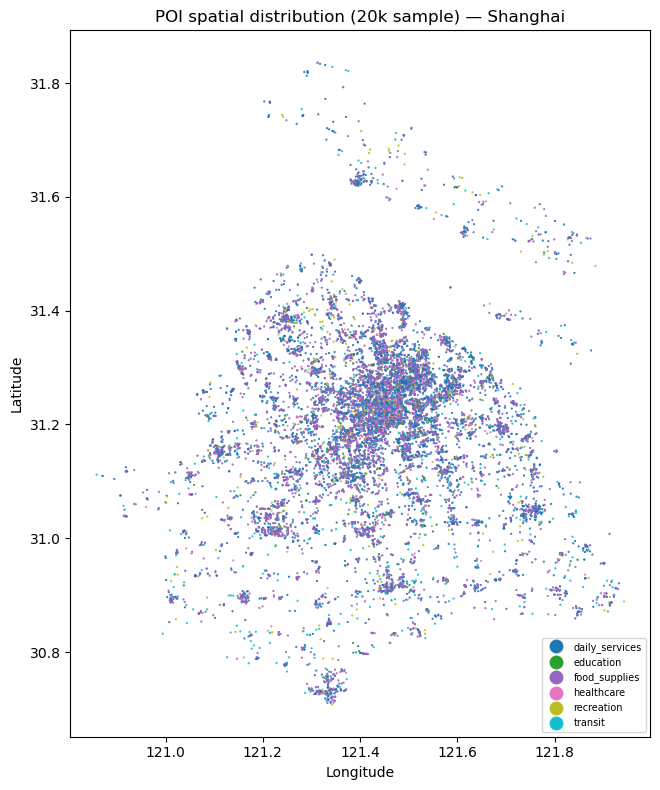

Saved → cache/poi_clean.parquet


In [5]:
# Convert to GeoDataFrame once for spatial ops later
from shapely.geometry import Point

poi_gdf = gpd.GeoDataFrame(
    poi_all,
    geometry=gpd.points_from_xy(poi_all['wgs84Lng'], poi_all['wgs84Lat']),
    crs='EPSG:4326'
)

# Summary by baseline indicator
summary = poi_gdf.groupby('baseline_indicator').size().rename('count').reset_index()
print(summary.to_string(index=False))

# Quick spatial check: plot distribution
fig, ax = plt.subplots(figsize=(8, 8))
poi_gdf.sample(min(20000, len(poi_gdf))).plot(
    column='baseline_indicator', ax=ax, markersize=0.3, legend=True,
    legend_kwds={'fontsize': 7, 'loc': 'lower right'}
)
ax.set_title('POI spatial distribution (20k sample) — Shanghai')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'poi_distribution.png', dpi=120)
plt.show()

# Save cleaned POI data
poi_gdf.to_parquet(CACHE_DIR / 'poi_clean.parquet')
print('Saved → cache/poi_clean.parquet')

## 3. Load & Validate Anjuke Real Estate Data (Track C)

In [6]:
anjuke = pd.read_csv(
    URBAN_DIR / 'UTSEUS-anjuke-real-estate.csv',
    usecols=['id', 'longitude', 'latitude', 'surface', 'price',
             'onesquaremeter', 'district', 'neighborhood'],
    encoding='utf-8'
)
print(f'Raw rows: {len(anjuke):,}')
print(anjuke.dtypes)
print(anjuke[['onesquaremeter', 'surface', 'price']].describe())

Raw rows: 467,029
id                    str
longitude         float64
latitude          float64
surface           float64
price             float64
onesquaremeter    float64
district              str
neighborhood          str
dtype: object
       onesquaremeter        surface         price
count    4.670290e+05  467029.000000  4.670290e+05
mean     5.745079e+04     103.661726  6.728775e+06
std      4.811677e+04      87.260206  1.234341e+07
min      7.692308e+02      10.000000  3.000000e+04
25%      3.647059e+04      58.000000  2.450000e+06
50%      5.528455e+04      85.000000  3.990000e+06
75%      7.428571e+04     119.000000  7.500000e+06
max      2.564077e+07    4097.000000  1.000000e+09


In [7]:
# Drop rows with missing coordinates or price
anjuke = anjuke.dropna(subset=['longitude', 'latitude', 'onesquaremeter'])

# Spatial bounds check (Shanghai)
anjuke = anjuke[
    (anjuke['longitude'].between(120.8, 122.2)) &
    (anjuke['latitude'].between(30.6, 31.9))
]

# Remove extreme outliers in rent/m² (IQR method)
q1 = anjuke['onesquaremeter'].quantile(0.01)
q99 = anjuke['onesquaremeter'].quantile(0.99)
anjuke = anjuke[anjuke['onesquaremeter'].between(q1, q99)]

print(f'Clean rows: {len(anjuke):,}')
print(f'Rent/m² range: {anjuke["onesquaremeter"].min():.0f} – {anjuke["onesquaremeter"].max():.0f} CNY/m²')
print(f'Median rent/m²: {anjuke["onesquaremeter"].median():.0f} CNY/m²')

# District coverage
print('\nListings per district:')
print(anjuke['district'].value_counts().to_string())

Clean rows: 445,182
Rent/m² range: 8286 – 145055 CNY/m²
Median rent/m²: 55301 CNY/m²

Listings per district:
district
pudong              75093
minhang             38940
xuhui               37625
baoshan             36689
putuo               28728
songjiang           27320
yangpu              22726
jiading             20553
fengxian            20454
hongkou             20313
changning           20274
qingpu              17929
huangpu             16270
luwan               14259
zhabei              14054
jingan              10854
chongming           10371
jinshan              9863
shanghaizhoubian     2867


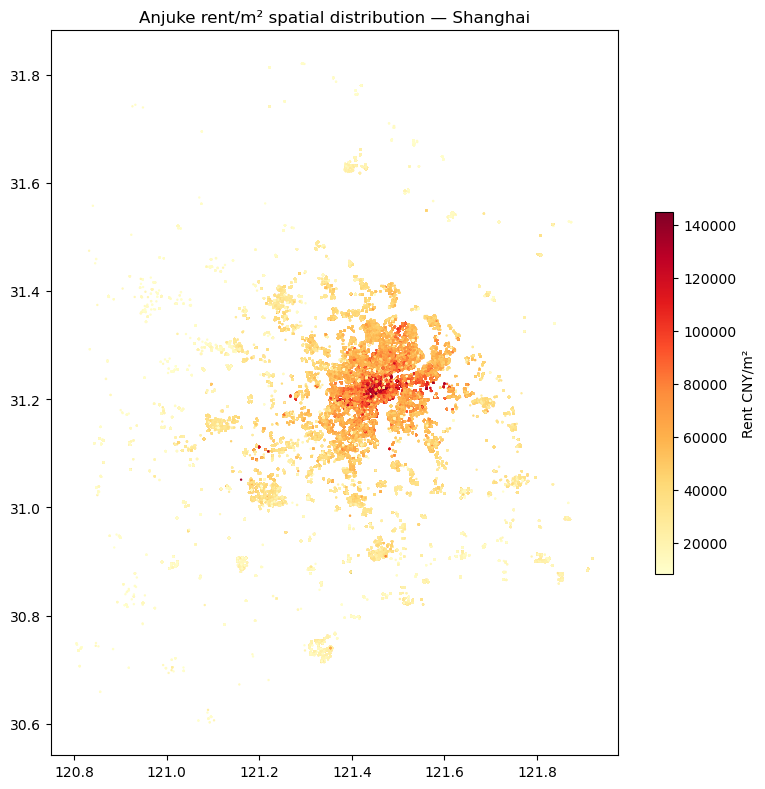

Saved → cache/anjuke_clean.parquet


In [8]:
anjuke_gdf = gpd.GeoDataFrame(
    anjuke,
    geometry=gpd.points_from_xy(anjuke['longitude'], anjuke['latitude']),
    crs='EPSG:4326'
)

# Plot rent/m² spatial distribution
fig, ax = plt.subplots(figsize=(8, 8))
anjuke_gdf.plot(
    column='onesquaremeter', ax=ax, markersize=0.5,
    cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Rent CNY/m²', 'shrink': 0.5}
)
ax.set_title('Anjuke rent/m² spatial distribution — Shanghai')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'anjuke_rent_distribution.png', dpi=120)
plt.show()

anjuke_gdf.to_parquet(CACHE_DIR / 'anjuke_clean.parquet')
print('Saved → cache/anjuke_clean.parquet')

### 3b. Social / Affordable Housing (Track C affordability)

The brief's affordability track includes *"presence and proximity of affordable / social housing"*.
AMap provides no dedicated social-housing category, so we extract affordable-housing communities by
**name** from the 商务住宅 (residential) category of the same 2023 SHP used for all baseline POIs —
talent apartments (人才公寓), public rental (公租房), resettlement (动迁/安置) housing, and other
guaranteed/low-rent (保障房/廉租/经济适用/共有产权) communities. These records are already geocoded
in WGS-84.

This is a **proximity proxy, not a housing census**: name-based matching misses communities with
neutral names and skews toward 人才公寓. Notebook 03 computes each hex's distance to the nearest
such community as the `social_housing_score`.

In [9]:
# ── Social / affordable housing for Track C affordability ────────────────────
# AMap has no dedicated social-housing tag, so we match by NAME on the residential
# subset of the 商务住宅 category in the same 2023 SHP used for all baseline POIs:
# talent apartments (人才公寓), public rental (公租房), resettlement (动迁/安置),
# and other guaranteed/low-rent housing (保障房/廉租/经济适用/共有产权).
import zipfile, pathlib
from collections import defaultdict

SH_KEYWORDS = '公租|公共租赁|保障房|保障性|廉租|动迁|安置|人才公寓|经济适用|共有产权|租赁住房|惠民'
SH_DROP     = '项目部|办理|管理处|管理所|办公|临时|指挥部|售楼|受理|服务中心|运营'  # offices, not housing

_tmp = pathlib.Path('/tmp/sh_work'); _tmp.mkdir(exist_ok=True)
res_shp = None
with zipfile.ZipFile(SHP_ZIP) as _zf:
    _ent = [e for e in _zf.infolist()
            if not e.filename.startswith('__MACOSX') and '.' in e.filename]
    _stems = defaultdict(list)
    for e in _ent:
        _stems[e.filename.rsplit('.', 1)[0]].append(e)
    for i, (stem, es) in enumerate(_stems.items()):
        if not any(e.filename.endswith('.shp') for e in es):
            continue
        for e in es:
            ext = e.filename.rsplit('.', 1)[1].lower()
            with _zf.open(e) as fin, open(_tmp / f's{i}.{ext}', 'wb') as fout:
                fout.write(fin.read())
        g = gpd.read_file(_tmp / f's{i}.shp')
        for p in _tmp.glob(f's{i}.*'):
            p.unlink()
        if '行业大' in g.columns and len(g) and g['行业大'].iloc[0] == '商务住宅':
            res_shp = g
            break

# Residential subset → name filter → drop management offices → spatial bounds
res = res_shp[res_shp['行业中'].astype(str).str.contains('住宅|宿舍|安置', na=False)]
sh  = res[res['name'].astype(str).str.contains(SH_KEYWORDS, na=False, regex=True)].copy()
sh  = sh[~sh['name'].astype(str).str.contains(SH_DROP, na=False, regex=True)]
sh  = sh[sh.geometry.notna()]
sh  = sh[sh.geometry.x.between(120.8, 122.2) & sh.geometry.y.between(30.6, 31.9)]

def _sh_cat(n):
    if '人才公寓' in n:                 return 'talent_apartment'
    if '公租' in n or '公共租赁' in n:   return 'public_rental'
    if '动迁' in n or '安置' in n:       return 'resettlement'
    if '保障' in n or '廉租' in n:       return 'guaranteed'
    return 'other_affordable'
sh['sh_category'] = sh['name'].map(_sh_cat)
sh['lng'] = sh.geometry.x
sh['lat'] = sh.geometry.y

sh_shp = gpd.GeoDataFrame(
    sh[['name', 'sh_category', 'lng', 'lat', 'geometry']].reset_index(drop=True),
    crs='EPSG:4326',
)

# ── Augment with the official 2024 保障性住房 project list ──────────────────────
# The SHP name-match above is a proxy; we add the official 上海市保障性住房项目 2024 list.
# PRIMARY SOURCES: 上海市房屋管理局 市筹公租房公示 (fgj.sh.gov.cn/ggzlzfgsgg, 2024-12) +
# 共有产权保障住房公示 (fgj.sh.gov.cn/gycqbzfgsgg) + 各区房管局/政府官网 人才公寓/安置房公示
# 2024 (闵行 zlzf.shmh.gov.cn · 松江 songjiang.gov.cn · 嘉定 fangguan.jiading.cn 等).
# 公租房/共有产权/保障性租赁/人才公寓; geocoded by name+address against the AMap 商务住宅 POI
# dump, then merged (deduped by ~150 m proximity to an SHP point). CAVEAT: 廉租 & 征收安置
# lack public address lists -> proximity proxy, not a census. (Compiled with AI assistance;
# see METHODOLOGY AI-assistance disclosure.)
import numpy as np, re as _re
from scipy.spatial import cKDTree as _KD
_proj = pd.read_csv('上海保障性住房项目2024.csv')
_amap = pd.read_csv('POI 2024/csv格式/已分类/上海市-1754933-utf8.csv-商务住宅.csv',
                    usecols=['name', 'address', 'wgs84Lng', 'wgs84Lat']).dropna(subset=['wgs84Lng'])
_DEV  = ['上海地产','地产集团','地产','集团','·','上海','恒基','旭辉','绿地','保利','万科',
         '招商','华润','中海','卓越','世茂','龙湖','中冶','禹洲']
_DIST = ['黄浦区','浦东新区','静安区','徐汇区','长宁区','普陀区','虹口区','杨浦区','闵行区',
         '宝山区','嘉定区','金山区','松江区','青浦区','奉贤区','崇明区']
def _nm(s):
    s = _re.sub(r'[（(].*?[)）]', '', str(s))
    for d in _DIST: s = s.replace(d, '')
    for w in _DEV + ['一期','二期','三期','项目','地块','市筹','区筹']: s = s.replace(w, '')
    return _re.sub(r'[\s年市]', '', s).strip()
def _ak(a):
    m = _re.search(r'([\u4e00-\u9fa5]{2,}(?:路|道|街)\d+弄)', str(a)); return m.group(1) if m else None
_amap['k'] = _amap['name'].map(_nm); _amap['ak'] = _amap['address'].map(_ak)
_nk, _aki = {}, {}
for _, r in _amap.iterrows():
    if r['k'] and r['k'] not in _nk:   _nk[r['k']]   = (r['wgs84Lng'], r['wgs84Lat'])
    if r['ak'] and r['ak'] not in _aki: _aki[r['ak']] = (r['wgs84Lng'], r['wgs84Lat'])
_keys = sorted(_nk, key=len, reverse=True)
_TYPEMAP = {'公共租赁住房':'public_rental','共有产权保障住房':'shared_ownership',
            '保障性租赁住房':'rental_assured','人才公寓':'talent_apartment','征收安置房':'resettlement'}
def _geocode(name, addr):
    k = _nm(name)
    if k in _nk: return _nk[k]
    for a in _keys:
        if min(len(k), len(a)) >= 4 and (k in a or a in k): return _nk[a]
    pa = _ak(addr)
    if pa and pa in _aki: return _aki[pa]
    return None
_rows = []
for _, r in _proj.iterrows():
    c = _geocode(r['name'], r['address'])
    if c: _rows.append({'name': r['name'], 'sh_category': _TYPEMAP.get(r['type'], 'other_affordable'),
                        'lng': c[0], 'lat': c[1]})
_new = gpd.GeoDataFrame(_rows, geometry=gpd.points_from_xy(
    [x['lng'] for x in _rows], [x['lat'] for x in _rows]), crs='EPSG:4326')
# Dedupe: drop new projects within 150 m of an existing SHP community
_a = sh_shp.to_crs('EPSG:32651'); _b = _new.to_crs('EPSG:32651')
_d, _ = _KD(np.column_stack([_a.geometry.x, _a.geometry.y])).query(
    np.column_stack([_b.geometry.x, _b.geometry.y]), k=1)
_keep = _new[_d > 150].copy()

social_housing = gpd.GeoDataFrame(
    pd.concat([sh_shp, _keep[['name','sh_category','lng','lat','geometry']]], ignore_index=True),
    geometry='geometry', crs='EPSG:4326')
social_housing.to_parquet(CACHE_DIR / 'social_housing.parquet')
print(f'Social housing: {len(sh_shp)} SHP-matched + {len(_keep)} new official '
      f'(of {len(_rows)} geocoded / {len(_proj)} projects) = {len(social_housing):,} total')
print(social_housing['sh_category'].value_counts().to_string())
print('Saved → cache/social_housing.parquet (proximity proxy in NB03 Track C)')

Social housing: 114 SHP-matched + 89 new official (of 89 geocoded / 112 projects) = 203 total
sh_category
talent_apartment    92
public_rental       42
shared_ownership    40
rental_assured      14
other_affordable     9
resettlement         6
Saved → cache/social_housing.parquet (proximity proxy in NB03 Track C)


## 4. Load Administrative Boundaries

In [10]:
# Neighbourhood polygons (28,750 features) — used for clipping the grid
neighbourhoods = gpd.read_file(URBAN_DIR / 'sh-neighbourhoods.geojson')
print(f'Neighbourhoods: {len(neighbourhoods)} features')
print(f'CRS: {neighbourhoods.crs}')
print(f'Columns: {list(neighbourhoods.columns)}')

# District boundaries (16 districts + 上海市 boundary)
districts = gpd.read_file(URBAN_DIR / 'sh-province-district.geojson')
print(f'\nDistricts: {len(districts)} features')
print(districts[['level', 'name']].to_string(index=False))

Neighbourhoods: 28750 features
CRS: EPSG:4326
Columns: ['Id', 'name', 'pname', 'cityname', 'type', 'adname', 'township', 'street', 'citycode', 'typecode', 'areacalc', 'aoilocac', 'adcode', 'geometry']

Districts: 18 features
   level name
province  上海市
    city 上海城区
district  黄浦区
district  徐汇区
district  长宁区
district  静安区
district  普陀区
district  虹口区
district  杨浦区
district  闵行区
district  宝山区
district  嘉定区
district 浦东新区
district  金山区
district  松江区
district  青浦区
district  奉贤区
district  崇明区


In [11]:
from shapely.ops import unary_union

# Shanghai outer boundary = union of all neighbourhood polygons
# (more precise than the single 上海市 polygon in districts)
shanghai_boundary = unary_union(neighbourhoods.geometry)
shanghai_gdf = gpd.GeoDataFrame(geometry=[shanghai_boundary], crs='EPSG:4326')

# Also keep the 16 districts (excluding 上海市 and 上海城区 which are duplicates)
district_polys = districts[districts['level'] == 'district'].copy()  
# adjust 'level' value if column has different content
if len(district_polys) == 0:
    # fallback: exclude the first two rows (市 and 城区 level)
    district_polys = districts.iloc[2:].copy()

print(f'Shanghai boundary bbox: {shanghai_boundary.bounds}')
print(f'Usable districts: {len(district_polys)}')

# Save
shanghai_gdf.to_file(CACHE_DIR / 'shanghai_boundary.geojson', driver='GeoJSON')
district_polys.to_file(CACHE_DIR / 'districts.geojson', driver='GeoJSON')
print('Saved boundary and districts to cache/')

Shanghai boundary bbox: (120.89459256698842, 30.7050753784236, 121.98562831288757, 31.8317916416716)
Usable districts: 16


Saved boundary and districts to cache/


## 5. Load Road Network

In [12]:
import pyarrow.parquet as pq

roads = gpd.read_parquet(DATA_DIR / 'shanghai-roads-simplified.parquet')
print(f'Edges: {len(roads):,}')
print(f'Columns: {list(roads.columns)}')
print(f'CRS: {roads.crs}')
print('\nMode availability:')
print(f'  foot=1:     {(roads["foot"]==1).sum():>7,} edges')
print(f'  bicycle=1:  {(roads["bicycle"]==1).sum():>7,} edges')
print(f'  motorcar=1: {(roads["motorcar"]==1).sum():>7,} edges')
print(f'\nmax_speed stats (known): {roads[roads["max_speed"]>0]["max_speed"].describe()}')

Edges: 156,432
Columns: ['u', 'v', 'osm_id', 'highway', 'level', 'lanes', 'width', 'bicycle', 'bicycle_safety', 'foot', 'foot_safety', 'max_speed', 'motorcar', 'geometry']
CRS: PROJCRS["New Beijing / Gauss-Kruger zone 21",BASEGEOGCRS["New Beijing",DATUM["New Beijing",ELLIPSOID["Krassowsky 1940",6378245,298.3,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4555]],CONVERSION["6-degree Gauss-Kruger zone 21",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",1,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",21500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["northing (X)",north,ORDER[1],LENGTHUNIT["metre",1]],AX

In [13]:
# Unique node count
all_nodes = pd.concat([
    roads[['u']].rename(columns={'u': 'node_id'}),
    roads[['v']].rename(columns={'v': 'node_id'})
]).drop_duplicates()
print(f'Unique nodes (intersections): {len(all_nodes):,}')
print(f'Directed edges: {len(roads):,}')
print(f'Avg degree: {len(roads)/len(all_nodes):.2f}')

Unique nodes (intersections): 109,891
Directed edges: 156,432
Avg degree: 1.42


## 6. Data Provenance

In [14]:
provenance = pd.DataFrame([
    {
        'Dataset':      'AMap (高德) POI Shanghai 2023 (SHP)',
        'Source':       'AMap export via project supervisor (UTSEUS)',
        'File':         '2023_Shp.zip (17 SHP files by category)',
        'Date':         '2023',
        'Licence':      'Academic use (UTSEUS)',
        'Rows':         f'{len(poi_all):,}  (after whitelist filtering)',
        'Used for':     '5 baseline indicators (food/health/recreation/transit/daily); Track C schools/libraries/clinics by midType',
        'Limitations':  'Snapshot 2023; education baseline now sourced from EDU 2026 instead (see below)'
    },
    {
        'Dataset':      'EDU 2026 Shanghai Schools (Gaode/AMap API) — education baseline source',
        'Source':       'Gaode/AMap WebService API, collected by project team member',
        'File':         'EDU 2026 POI.zip / preschool_k12_clean.csv',
        'Date':         '2026-06',
        'Licence':      'Academic use',
        'Rows':         f'{len(edu_raw):,}',
        'Used for':     'Education baseline indicator (primary source: K-12 + kindergarten)',
        'Limitations':  'K-12 + kindergarten only; GCJ-02->WGS-84 converted; 2026 vintage vs 2023 base (schools are stable infrastructure)'
    },
    {
        'Dataset':      'Anjuke real estate listings',
        'Source':       'UTSEUS dataset (scraped from anjuke.com)',
        'File':         'urban data/UTSEUS-anjuke-real-estate.csv',
        'Date':         'Unknown (pre-2024)',
        'Licence':      'Academic use (UTSEUS)',
        'Rows':         f'{len(anjuke):,}',
        'Used for':     'Track C — price per m² per neighbourhood',
        'Limitations':  'Sale listings (not rental); snapshot in time; coverage varies by district'
    },
    {
        'Dataset':      'Social / affordable housing (derived from 2023 SHP)',
        'Source':       'Name-matched from AMap 商务住宅 category (2023_Shp.zip)',
        'File':         'cache/social_housing.parquet',
        'Date':         '2023',
        'Licence':      'Academic use (UTSEUS)',
        'Rows':         f'{len(social_housing):,}',
        'Used for':     'Track C — proximity to affordable/social housing',
        'Limitations':  'Name-based proxy; undercounts neutral-named communities; skews to 人才公寓'
    },
    {
        'Dataset':      'Shanghai neighbourhood polygons',
        'Source':       'UTSEUS (OpenStreetMap derived)',
        'File':         'urban data/sh-neighbourhoods.geojson',
        'Date':         'Unknown',
        'Licence':      'ODbL (OpenStreetMap)',
        'Rows':         f'{len(neighbourhoods):,} polygons',
        'Used for':     'Shanghai boundary for grid clipping',
        'Limitations':  'Neighbourhood boundaries may not reflect admin divisions precisely'
    },
    {
        'Dataset':      'Shanghai district boundaries',
        'Source':       'UTSEUS',
        'File':         'urban data/sh-province-district.geojson',
        'Date':         'Unknown',
        'Licence':      'Academic use (UTSEUS)',
        'Rows':         f'{len(districts)} polygons',
        'Used for':     'District-level aggregation and regression',
        'Limitations':  'None significant'
    },
    {
        'Dataset':      'Shanghai road network (simplified)',
        'Source':       'OpenStreetMap via policosm (UTSEUS)',
        'File':         'shanghai-roads-simplified.parquet',
        'Date':         '2023',
        'Licence':      'ODbL (OpenStreetMap)',
        'Rows':         f'{len(roads):,} edges',
        'Used for':     'Network-based isochrone computation (Notebooks 02–03)',
        'Limitations':  'Simplified topology; some pedestrian paths may be missing'
    },
])

print(provenance[['Dataset', 'Rows', 'Used for']].to_string(index=False))
provenance.to_csv(CACHE_DIR / 'data_provenance.csv', index=False)
print('\nFull provenance saved → cache/data_provenance.csv')

                                                               Dataset                                 Rows                                                                                                   Used for
                                     AMap (高德) POI Shanghai 2023 (SHP) 540,317  (after whitelist filtering) 5 baseline indicators (food/health/recreation/transit/daily); Track C schools/libraries/clinics by midType
EDU 2026 Shanghai Schools (Gaode/AMap API) — education baseline source                                4,050                                         Education baseline indicator (primary source: K-12 + kindergarten)
                                           Anjuke real estate listings                              445,182                                                                   Track C — price per m² per neighbourhood
                   Social / affordable housing (derived from 2023 SHP)                                  203                                 

## Summary

Notebook 01 complete. All raw data loaded, validated, and cached to `cache/`:

| Cache file | Contents |
|---|---|
| `poi_clean.parquet` | All relevant POIs from 2023 SHP with WGS-84 coords and indicator labels |
| `anjuke_clean.parquet` | 445k rent listings, cleaned and bounded |
| `social_housing.parquet` | Affordable-housing communities (name-matched from 2023 SHP) for Track C |
| `shanghai_boundary.geojson` | Shanghai outer boundary polygon |
| `districts.geojson` | 16 district polygons |
| `data_provenance.csv` | Full provenance table |

**⚠ Stale cache — must regenerate before Notebook 03:**
- `cache/accessibility_matrix.parquet` was computed from the old 2024 CSV POI data.
  Delete it and re-run all cells in `02_grid_isochrones.ipynb` to rebuild with 2023 SHP POIs.

→ Proceed to `02_grid_isochrones.ipynb`